
LOADING VAHAN DATA

Dataset shape:
(418372, 9)

Original columns:
['id', 'date', 'state_name', 'state_code', 'office_name', 'office_code', 'fuel_type', 'category', 'registrations']

Normalized columns:
['id', 'date', 'state_name', 'state_code', 'office_name', 'office_code', 'fuel_type', 'category', 'registrations']

Detected columns:
Date: date
Fuel: fuel_type
Count: registrations

CLEANING DATA

Fuel types found:
fuel_type
PETROL                 82094
DIESEL                 81597
PETROL/HYBRID          59219
ELECTRIC(BOV)          55305
PETROL/CNG             43149
CNG ONLY               23074
NOT APPLICABLE         22206
PETROL/ETHANOL         15582
PETROL/LPG             13373
DIESEL/HYBRID          11001
LPG ONLY                8452
STRONG HYBRID EV        1470
PURE EV                 1462
LNG                      134
ETHANOL                   82
DUAL DIESEL/CNG           73
METHANOL                  55
DUAL DIESEL/BIO CNG       20
SOLAR                      8
DUAL DIESEL/LNG     

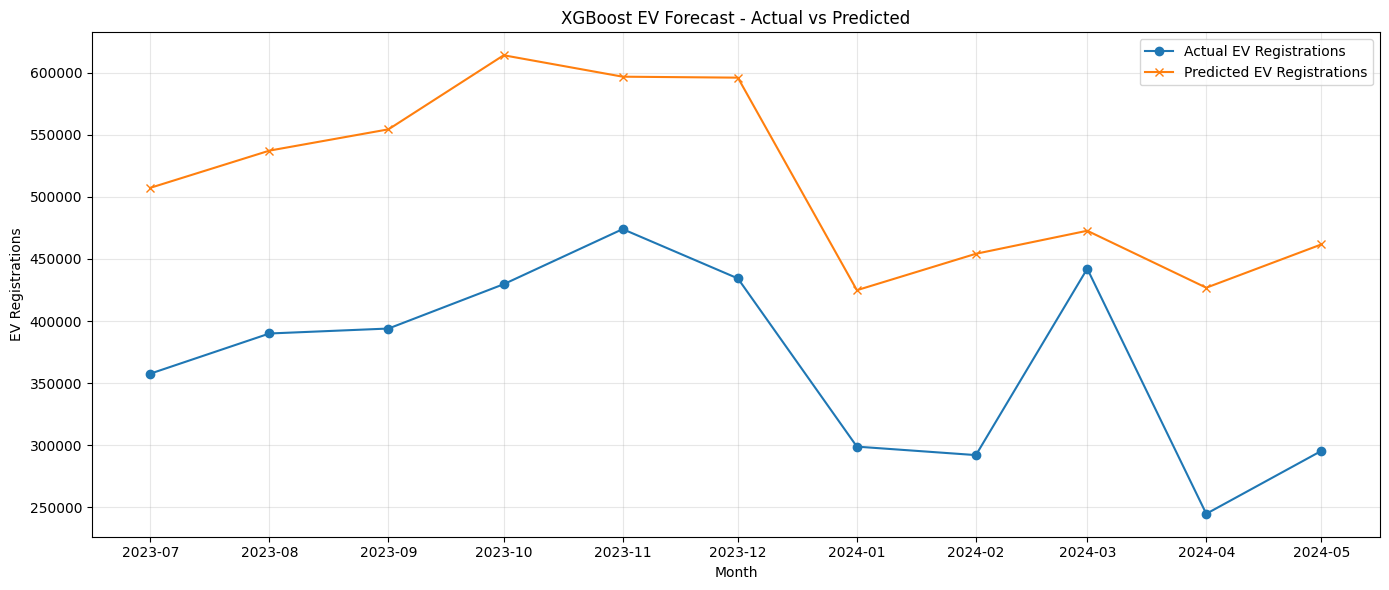


FORECASTING FUTURE EV DEMAND

Future forecast:
        month   forecast_ev
0  2024-06-01  452188.06250
1  2024-07-01  448677.06250
2  2024-08-01  492343.46875
3  2024-09-01  510349.71875
4  2024-10-01  596272.87500
5  2024-11-01  650059.31250
6  2024-12-01  660635.93750
7  2025-01-01  441661.40625
8  2025-02-01  414683.71875
9  2025-03-01  499361.50000
10 2025-04-01  461364.59375
11 2025-05-01  441179.65625

FORECAST SUMMARY
Latest monthly EV registrations: 295,388
Forecast after 36 months: 437,477
Estimated growth: 48.10%


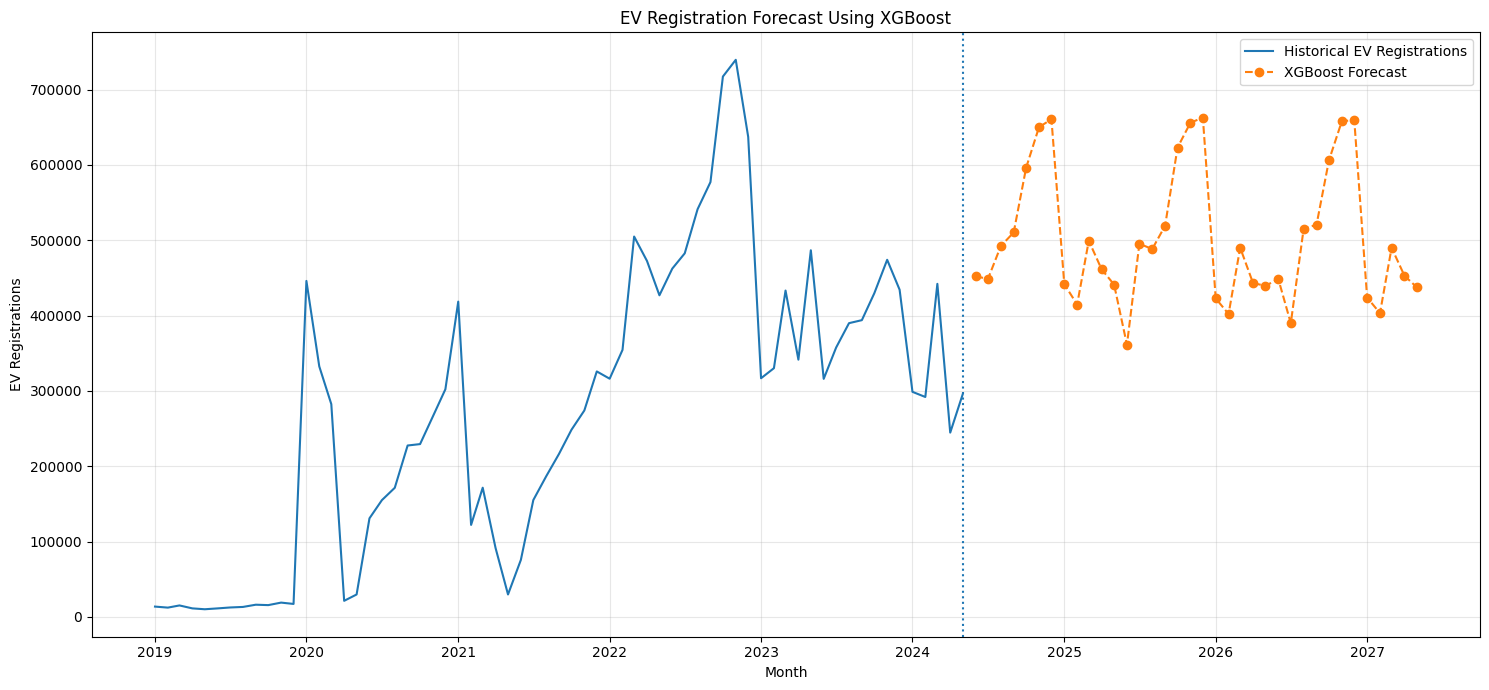


FEATURE IMPORTANCE
            feature  importance
3        time_index    0.284861
0              year    0.191617
11  rolling_mean_12    0.179231
2           quarter    0.121305
1      month_number    0.059239
10   rolling_mean_6    0.058502
4             lag_1    0.022904
9    rolling_mean_3    0.022161
6             lag_3    0.021470
7             lag_6    0.013868
8            lag_12    0.012952
5             lag_2    0.011890

PIPELINE COMPLETED

Generated files:

models/
    ev_xgboost_model.pkl

outputs/
    test_predictions.csv
    future_ev_forecast.csv
    actual_vs_predicted.png
    future_ev_forecast.png
    feature_importance.csv



In [2]:
# ============================================================
# EV FORECASTING USING VAHAN + XGBOOST REGRESSOR
# ============================================================

import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_PATH = "/content/vahan-vehicle-registrations-by-fuel-type-nmiqeb.csv"

OUTPUT_DIR = "outputs"
MODEL_DIR = "models"

FORECAST_MONTHS = 36

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


# ============================================================
# 2. LOAD DATA
# ============================================================

print("\n======================================")
print("LOADING VAHAN DATA")
print("======================================")

if DATA_PATH.endswith(".csv"):

    df = pd.read_csv(DATA_PATH)

elif DATA_PATH.endswith(".xlsx"):

    df = pd.read_excel(DATA_PATH)

else:

    raise ValueError(
        "Only CSV and XLSX files are supported."
    )


print("\nDataset shape:")
print(df.shape)

print("\nOriginal columns:")
print(df.columns.tolist())


# ============================================================
# 3. NORMALIZE COLUMN NAMES
# ============================================================

def normalize_column(column):

    column = str(column).strip().lower()

    column = re.sub(
        r"[^a-z0-9]+",
        "_",
        column
    )

    column = column.strip("_")

    return column


df.columns = [
    normalize_column(col)
    for col in df.columns
]

print("\nNormalized columns:")
print(df.columns.tolist())


# ============================================================
# 4. FIND IMPORTANT COLUMNS
# ============================================================

def find_column(columns, candidates):

    for candidate in candidates:

        for column in columns:

            if candidate == column:
                return column

    for candidate in candidates:

        for column in columns:

            if candidate in column:
                return column

    return None


date_column = find_column(
    df.columns,
    [
        "date",
        "month",
        "year_month",
        "registration_date",
        "registration_month",
        "month_year"
    ]
)


fuel_column = find_column(
    df.columns,
    [
        "fuel_type",
        "fuel",
        "fueltype",
        "fuel_powertrain"
    ]
)


count_column = find_column(
    df.columns,
    [
        "registrations",
        "registration_count",
        "registration",
        "count",
        "vehicle_count",
        "total"
    ]
)


print("\nDetected columns:")

print("Date:", date_column)
print("Fuel:", fuel_column)
print("Count:", count_column)


if date_column is None:

    raise ValueError(
        """
        Date/month column was not detected.

        Please check df.columns and update
        the date_column candidates.
        """
    )


if fuel_column is None:

    raise ValueError(
        """
        Fuel type column was not detected.

        Please check df.columns and update
        the fuel_column candidates.
        """
    )


if count_column is None:

    raise ValueError(
        """
        Registration count column was not detected.

        Please check df.columns and update
        the count_column candidates.
        """
    )


# ============================================================
# 5. BASIC CLEANING
# ============================================================

print("\n======================================")
print("CLEANING DATA")
print("======================================")


df = df.drop_duplicates()


df[fuel_column] = (
    df[fuel_column]
    .astype(str)
    .str.strip()
    .str.upper()
)


df[date_column] = pd.to_datetime(
    df[date_column],
    errors="coerce"
)


df[count_column] = pd.to_numeric(
    df[count_column],
    errors="coerce"
)


df = df.dropna(
    subset=[
        date_column,
        fuel_column,
        count_column
    ]
)


# ============================================================
# 6. CHECK FUEL TYPES
# ============================================================

print("\nFuel types found:")

print(
    df[fuel_column]
    .value_counts()
    .head(30)
)


# ============================================================
# 7. FILTER ELECTRIC VEHICLES
# ============================================================

electric_keywords = [
    "ELECTRIC",
    "PURE EV",
    "EV",
    "BATTERY"
]


def is_electric(value):

    value = str(value).upper()

    return any(
        keyword in value
        for keyword in electric_keywords
    )


ev_df = df[
    df[fuel_column].apply(is_electric)
].copy()


print("\nEV records:", len(ev_df))


if len(ev_df) == 0:

    raise ValueError(
        """
        No electric vehicle records were found.

        Check the printed fuel types and
        update electric_keywords.
        """
    )


# ============================================================
# 8. CREATE MONTHLY EV DATASET
# ============================================================

ev_df["month"] = (
    ev_df[date_column]
    .dt.to_period("M")
    .dt.to_timestamp()
)


monthly_ev = (
    ev_df
    .groupby("month")[count_column]
    .sum()
    .reset_index()
)


monthly_ev = monthly_ev.rename(
    columns={
        count_column: "ev_registrations"
    }
)


monthly_ev = monthly_ev.sort_values(
    "month"
)


print("\nMonthly EV data:")
print(monthly_ev.head(10))


print("\nDate range:")

print(
    monthly_ev["month"].min(),
    "to",
    monthly_ev["month"].max()
)


# ============================================================
# 9. FILL MISSING MONTHS
# ============================================================

full_dates = pd.date_range(
    start=monthly_ev["month"].min(),
    end=monthly_ev["month"].max(),
    freq="MS"
)


monthly_ev = (
    monthly_ev
    .set_index("month")
    .reindex(full_dates)
)


monthly_ev.index.name = "month"


monthly_ev["ev_registrations"] = (
    monthly_ev["ev_registrations"]
    .fillna(0)
)


monthly_ev = monthly_ev.reset_index()


# ============================================================
# 10. CREATE TIME FEATURES
# ============================================================

monthly_ev["year"] = (
    monthly_ev["month"].dt.year
)

monthly_ev["month_number"] = (
    monthly_ev["month"].dt.month
)

monthly_ev["quarter"] = (
    monthly_ev["month"].dt.quarter
)


monthly_ev["time_index"] = (
    np.arange(len(monthly_ev))
)


# ============================================================
# 11. CREATE LAG FEATURES
# ============================================================

monthly_ev["lag_1"] = (
    monthly_ev["ev_registrations"]
    .shift(1)
)

monthly_ev["lag_2"] = (
    monthly_ev["ev_registrations"]
    .shift(2)
)

monthly_ev["lag_3"] = (
    monthly_ev["ev_registrations"]
    .shift(3)
)

monthly_ev["lag_6"] = (
    monthly_ev["ev_registrations"]
    .shift(6)
)

monthly_ev["lag_12"] = (
    monthly_ev["ev_registrations"]
    .shift(12)
)


# ============================================================
# 12. ROLLING FEATURES
# ============================================================

monthly_ev["rolling_mean_3"] = (
    monthly_ev["ev_registrations"]
    .shift(1)
    .rolling(3)
    .mean()
)


monthly_ev["rolling_mean_6"] = (
    monthly_ev["ev_registrations"]
    .shift(1)
    .rolling(6)
    .mean()
)


monthly_ev["rolling_mean_12"] = (
    monthly_ev["ev_registrations"]
    .shift(1)
    .rolling(12)
    .mean()
)


# ============================================================
# 13. REMOVE INITIAL NaN ROWS
# ============================================================

model_df = monthly_ev.dropna().copy()


print("\nModel dataset shape:")
print(model_df.shape)


# ============================================================
# 14. DEFINE FEATURES
# ============================================================

features = [

    "year",
    "month_number",
    "quarter",
    "time_index",

    "lag_1",
    "lag_2",
    "lag_3",

    "lag_6",
    "lag_12",

    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_12"

]


target = "ev_registrations"


X = model_df[features]

y = model_df[target]


# ============================================================
# 15. TIME-BASED TRAIN TEST SPLIT
# ============================================================

print("\n======================================")
print("TRAIN / TEST SPLIT")
print("======================================")


split_index = int(
    len(model_df) * 0.80
)


X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]


y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]


print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))


# ============================================================
# 16. TRAIN XGBOOST
# ============================================================

print("\n======================================")
print("TRAINING XGBOOST")
print("======================================")


model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1

)


model.fit(
    X_train,
    y_train
)


print("Training completed.")


# ============================================================
# 17. TEST PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)


# ============================================================
# 18. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


r2 = r2_score(
    y_test,
    y_pred
)


print("\n======================================")
print("MODEL PERFORMANCE")
print("======================================")


print(
    f"MAE  : {mae:,.2f}"
)

print(
    f"RMSE : {rmse:,.2f}"
)

print(
    f"R²   : {r2:.4f}"
)


# ============================================================
# 19. SAVE MODEL
# ============================================================

model_path = (
    f"{MODEL_DIR}/ev_xgboost_model.pkl"
)


joblib.dump(
    model,
    model_path
)


print(
    "\nModel saved:",
    model_path
)


# ============================================================
# 20. TEST RESULT DATAFRAME
# ============================================================

test_results = model_df.iloc[
    split_index:
].copy()


test_results["predicted_ev"] = y_pred


test_results.to_csv(
    f"{OUTPUT_DIR}/test_predictions.csv",
    index=False
)


# ============================================================
# 21. PLOT ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(14, 6)
)


plt.plot(
    test_results["month"],
    test_results["ev_registrations"],
    label="Actual EV Registrations",
    marker="o"
)


plt.plot(
    test_results["month"],
    test_results["predicted_ev"],
    label="Predicted EV Registrations",
    marker="x"
)


plt.title(
    "XGBoost EV Forecast - Actual vs Predicted"
)


plt.xlabel("Month")

plt.ylabel(
    "EV Registrations"
)


plt.legend()

plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/actual_vs_predicted.png",
    dpi=300
)


plt.show()


# ============================================================
# 22. FUTURE FORECAST FUNCTION
# ============================================================

def create_future_features(
    history,
    future_date
):

    temp = history.copy()


    temp = temp.sort_values(
        "month"
    )


    values = (
        temp["ev_registrations"]
        .tolist()
    )


    time_index = len(temp)


    row = {

        "year":
            future_date.year,

        "month_number":
            future_date.month,

        "quarter":
            future_date.quarter,

        "time_index":
            time_index,

        "lag_1":
            values[-1],

        "lag_2":
            values[-2],

        "lag_3":
            values[-3],

        "lag_6":
            values[-6],

        "lag_12":
            values[-12],

        "rolling_mean_3":
            np.mean(values[-3:]),

        "rolling_mean_6":
            np.mean(values[-6:]),

        "rolling_mean_12":
            np.mean(values[-12:])

    }


    return pd.DataFrame(
        [row]
    )


# ============================================================
# 23. RECURSIVE FUTURE FORECAST
# ============================================================

print("\n======================================")
print("FORECASTING FUTURE EV DEMAND")
print("======================================")


history = monthly_ev[
    [
        "month",
        "ev_registrations"
    ]
].copy()


last_date = (
    history["month"].max()
)


future_dates = pd.date_range(

    start=(
        last_date
        + pd.offsets.MonthBegin(1)
    ),

    periods=FORECAST_MONTHS,

    freq="MS"

)


future_predictions = []


for future_date in future_dates:

    X_future = create_future_features(
        history,
        future_date
    )


    prediction = model.predict(
        X_future[features]
    )[0]


    # Prevent unrealistic negative demand
    prediction = max(
        0,
        prediction
    )


    future_predictions.append({

        "month":
            future_date,

        "forecast_ev":
            prediction

    })


    # Add prediction to history
    history = pd.concat(

        [
            history,

            pd.DataFrame(
                {
                    "month":
                        [future_date],

                    "ev_registrations":
                        [prediction]
                }
            )

        ],

        ignore_index=True

    )


forecast_df = pd.DataFrame(
    future_predictions
)


# ============================================================
# 24. SAVE FORECAST
# ============================================================

forecast_df.to_csv(

    f"{OUTPUT_DIR}/future_ev_forecast.csv",

    index=False

)


print("\nFuture forecast:")

print(
    forecast_df.head(12)
)


# ============================================================
# 25. FORECAST SUMMARY
# ============================================================

current_ev = (
    monthly_ev
    ["ev_registrations"]
    .iloc[-1]
)


future_ev = (
    forecast_df
    ["forecast_ev"]
    .iloc[-1]
)


growth = (

    (
        future_ev
        -
        current_ev
    )
    /
    current_ev
) * 100


print("\n======================================")
print("FORECAST SUMMARY")
print("======================================")


print(
    f"Latest monthly EV registrations: "
    f"{current_ev:,.0f}"
)


print(
    f"Forecast after {FORECAST_MONTHS} months: "
    f"{future_ev:,.0f}"
)


print(
    f"Estimated growth: "
    f"{growth:.2f}%"
)


# ============================================================
# 26. PLOT FUTURE FORECAST
# ============================================================

plt.figure(
    figsize=(15, 7)
)


plt.plot(

    monthly_ev["month"],

    monthly_ev["ev_registrations"],

    label="Historical EV Registrations"

)


plt.plot(

    forecast_df["month"],

    forecast_df["forecast_ev"],

    label="XGBoost Forecast",

    linestyle="--",

    marker="o"

)


plt.axvline(

    x=last_date,

    linestyle=":"

)


plt.title(
    "EV Registration Forecast Using XGBoost"
)


plt.xlabel(
    "Month"
)


plt.ylabel(
    "EV Registrations"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    f"{OUTPUT_DIR}/future_ev_forecast.png",

    dpi=300

)


plt.show()


# ============================================================
# 27. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "feature":
        features,

    "importance":
        model.feature_importances_

})


importance = importance.sort_values(

    "importance",

    ascending=False

)


print("\n======================================")
print("FEATURE IMPORTANCE")
print("======================================")


print(
    importance
)


importance.to_csv(

    f"{OUTPUT_DIR}/feature_importance.csv",

    index=False

)


# ============================================================
# 28. FINAL OUTPUT
# ============================================================

print("\n======================================")
print("PIPELINE COMPLETED")
print("======================================")


print(
    """
Generated files:

models/
    ev_xgboost_model.pkl

outputs/
    test_predictions.csv
    future_ev_forecast.csv
    actual_vs_predicted.png
    future_ev_forecast.png
    feature_importance.csv
"""
)